# 05 AMEX Metric Model Selection

This notebook selects among the fitted model artifacts produced by `04_supervised_modeling.ipynb`.
It does **not** train fresh model families. The workflow is:

1. `04` trains representative supervised models and exports fitted `.joblib` artifacts under
   `models/supervised/`.
2. `05` reloads those artifacts, scores them with the official AMEX metric, and compares rankings
   under AMEX-M, ROC-AUC, and PR-AUC.
3. `06` interprets the same fitted artifacts.

This makes model selection reproducible and keeps the metric notebook focused on the selection rule,
not another round of training.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# Works whether Jupyter starts in project root or notebooks/.
if Path('notebooks').exists():
    PROJECT = Path('.')
else:
    PROJECT = Path('..')

INTERIM = PROJECT / 'data' / 'interim'
REPORTS = PROJECT / 'reports' / 'modeling'
MODEL_DIR = PROJECT / 'models' / 'supervised'
REPORTS.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = INTERIM / 'train_features.parquet'
HOLDOUT_PATH = INTERIM / 'test_features_holdout.parquet'
MANIFEST_PATH = MODEL_DIR / 'model_artifact_manifest.csv'
SCHEMA_PATH = MODEL_DIR / 'feature_schema.json'

assert FEATURES_PATH.exists(), 'Run notebooks/03_feature_engineering.ipynb first to create train_features.parquet.'
assert MANIFEST_PATH.exists(), 'Run notebooks/04_supervised_modeling.ipynb through the model artifact export cell before running 05.'
assert SCHEMA_PATH.exists(), 'Run notebooks/04_supervised_modeling.ipynb through the model artifact export cell before running 05.'

features = pd.read_parquet(FEATURES_PATH)
y = features['target'].astype(int)
X = features.drop(columns='target')

schema = json.loads(SCHEMA_PATH.read_text())
SEED = int(schema.get('seed', 5241))
assert list(X.columns) == schema['feature_columns'], 'Current train_features.parquet schema differs from the saved model schema. Rerun 04.'

# Recreate the exact internal test split used by 04.
X_train, X_internal, y_train, y_internal = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

if HOLDOUT_PATH.exists():
    holdout = pd.read_parquet(HOLDOUT_PATH)
    X_holdout = holdout.drop(columns='target')
    y_holdout = holdout['target'].astype(int)
    assert list(X_holdout.columns) == list(X.columns), 'holdout schema does not match train feature schema'
else:
    X_holdout = y_holdout = None

artifact_manifest = pd.read_csv(MANIFEST_PATH)
models = {}
for _, row in artifact_manifest.iterrows():
    path = Path(row['artifact_path'])
    if not path.is_absolute():
        path = PROJECT / path
    if path.exists():
        models[row['model']] = joblib.load(path)
    else:
        print(f"missing artifact for {row['model']}: {path}")

# Use representative family artifacts for selection. `final_model` is shown separately because it is
# already the model selected in 04 and can duplicate one of these candidates.
selection_models = [
    name for name in [
        'regularized_lr', 'linear_svm', 'decision_tree', 'random_forest', 'histgb',
        'xgboost', 'lgbm_tuned', 'gaussian_nb', 'lda', 'mlp'
    ]
    if name in models
]

assert selection_models, 'No usable fitted model artifacts found. Rerun 04 through the model artifact export cell.'
print(f'loaded {len(models)} artifacts from {MODEL_DIR}')
print(f'selection candidates: {selection_models}')
print(f'internal test: {X_internal.shape}; target rate {y_internal.mean():.3f}')
if X_holdout is not None:
    print(f'holdout: {X_holdout.shape}; target rate {y_holdout.mean():.3f}')


loaded 12 artifacts from ../models/supervised
selection candidates: ['regularized_lr', 'linear_svm', 'decision_tree', 'random_forest', 'histgb', 'xgboost', 'lgbm_tuned', 'gaussian_nb', 'lda', 'mlp']
internal test: (16625, 968); target rate 0.270
holdout: (83053, 968); target rate 0.268


## AMEX Metric Scorer

`amex_M = 0.5 * (G + D)`, where `G` is normalized weighted Gini and `D` is default capture in the
top 4% of weighted observations. This is a ranking metric, so it can use probabilities or raw
continuous decision scores.

In [2]:
def amex_metric(y_true, y_pred):
    """Official AMEX metric: mean of normalized weighted Gini and default capture at top 4%."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    labels = np.transpose(np.array([y_true, y_pred]))
    labels = labels[labels[:, 1].argsort()[::-1]]
    weights = np.where(labels[:, 0] == 0, 20, 1)
    cutoff = int(0.04 * np.sum(weights))
    top = labels[np.cumsum(weights) <= cutoff]
    default_capture = top[:, 0].sum() / labels[:, 0].sum()

    gini = [0.0, 0.0]
    for i in [1, 0]:
        labels = np.transpose(np.array([y_true, y_pred]))
        labels = labels[labels[:, i].argsort()[::-1]]
        weights = np.where(labels[:, 0] == 0, 20, 1)
        random = np.cumsum(weights / weights.sum())
        lorentz = np.cumsum(labels[:, 0] * weights) / np.sum(labels[:, 0] * weights)
        gini[i] = np.sum((lorentz - random) * weights)

    normalized_gini = gini[1] / gini[0]
    return 0.5 * (normalized_gini + default_capture), normalized_gini, default_capture


def model_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_eval)
    return model.predict(X_eval)


def score_frame(y_true, scores):
    M, G, D = amex_metric(y_true, scores)
    return {
        'amex_M': M,
        'gini_G': G,
        'capture_D@4pct': D,
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
    }

print('AMEX scorer ready')


AMEX scorer ready


## Internal Test Ranking From `04` Artifacts

These scores are computed on the same internal held-out split created in `04`. No models are refit
here; every row comes from a fitted artifact saved by `04`.

,model,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,rank_by_amex_M,rank_by_roc_auc,rank_by_pr_auc
0,regularized_lr,0.7719,0.9101,0.6336,0.9551,0.8895,1,2,2
1,lgbm_tuned,0.7716,0.9102,0.6330,0.9551,0.8908,2,1,1
2,xgboost,0.7669,0.9100,0.6238,0.9550,0.8894,3,3,3
3,linear_svm,0.7666,0.9061,0.6272,0.9531,0.8840,4,4,5
4,mlp,0.7662,0.9052,0.6272,0.9526,0.8828,5,6,6
5,lda,0.7600,0.9036,0.6165,0.9518,0.8784,6,7,7
6,histgb,0.7576,0.9060,0.6091,0.9530,0.8853,7,5,4
7,random_forest,0.7398,0.8975,0.5821,0.9488,0.8735,8,8,8
8,decision_tree,0.6626,0.8451,0.4801,0.9225,0.7997,9,9,9
9,gaussian_nb,0.5294,0.8115,0.2472,0.9039,0.6850,10,10,10


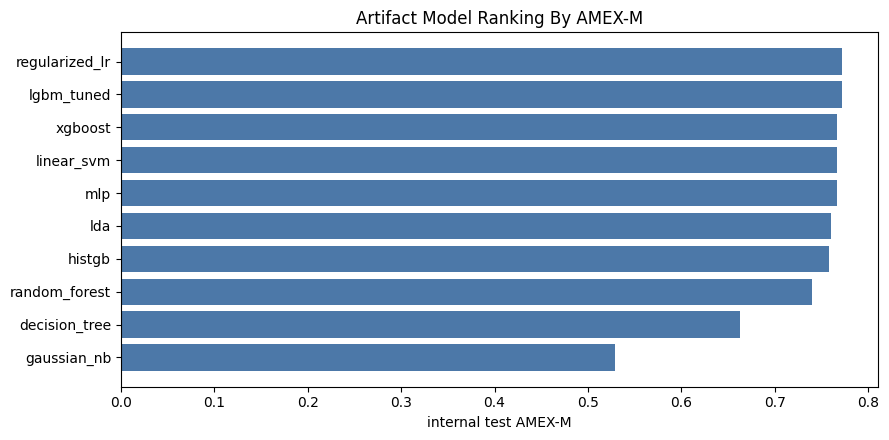

In [3]:
internal_rows = []
for name in selection_models:
    scores = model_scores(models[name], X_internal)
    internal_rows.append({'model': name, **score_frame(y_internal, scores)})

internal_rank = pd.DataFrame(internal_rows).sort_values('amex_M', ascending=False).reset_index(drop=True)
internal_rank['rank_by_amex_M'] = internal_rank['amex_M'].rank(ascending=False, method='min').astype(int)
internal_rank['rank_by_roc_auc'] = internal_rank['roc_auc'].rank(ascending=False, method='min').astype(int)
internal_rank['rank_by_pr_auc'] = internal_rank['pr_auc'].rank(ascending=False, method='min').astype(int)
internal_rank.to_csv(REPORTS / 'amex_metric_artifact_internal_ranking.csv', index=False)
display(internal_rank.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = internal_rank.sort_values('amex_M')
ax.barh(plot_df['model'], plot_df['amex_M'], color='#4C78A8')
ax.set_xlabel('internal test AMEX-M')
ax.set_title('Artifact Model Ranking By AMEX-M')
fig.tight_layout(); fig.savefig(REPORTS / 'amex_metric_artifact_internal_ranking.png', dpi=160); plt.show()


## Optional Disjoint Hold-Out Ranking

If `test_features_holdout.parquet` is available, this repeats the artifact scoring on the disjoint
hold-out customers. This is usually the most relevant selection table because the customers are
separate from the modeling subset.

,model,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,rank_by_amex_M,rank_by_roc_auc,rank_by_pr_auc
0,lgbm_tuned,0.7826,0.9190,0.6462,0.9595,0.8970,1,1,1
1,xgboost,0.7801,0.9181,0.6421,0.9590,0.8959,2,2,2
2,histgb,0.7786,0.9159,0.6414,0.9580,0.8934,3,4,4
3,regularized_lr,0.7775,0.9165,0.6384,0.9583,0.8935,4,3,3
4,mlp,0.7681,0.9118,0.6243,0.9559,0.8870,5,5,5
5,lda,0.7598,0.9055,0.6140,0.9528,0.8803,6,6,6
6,linear_svm,0.7537,0.8969,0.6105,0.9485,0.8780,7,8,8
7,random_forest,0.7524,0.9055,0.5993,0.9527,0.8781,8,7,7
8,decision_tree,0.6826,0.8590,0.5061,0.9293,0.8140,9,9,9
9,gaussian_nb,0.3027,0.5216,0.0839,0.7601,0.4348,10,10,10


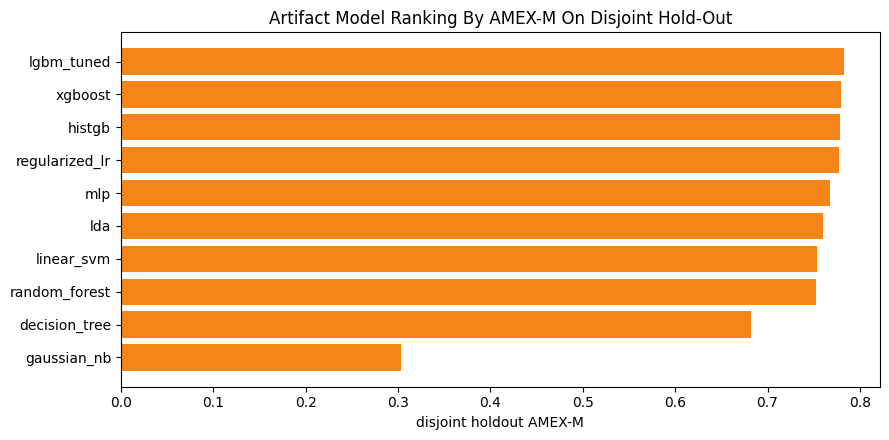

In [4]:
if X_holdout is None:
    holdout_rank = None
    print('Holdout feature table not found; skipping disjoint hold-out artifact ranking.')
else:
    holdout_rows = []
    for name in selection_models:
        scores = model_scores(models[name], X_holdout)
        holdout_rows.append({'model': name, **score_frame(y_holdout, scores)})
    holdout_rank = pd.DataFrame(holdout_rows).sort_values('amex_M', ascending=False).reset_index(drop=True)
    holdout_rank['rank_by_amex_M'] = holdout_rank['amex_M'].rank(ascending=False, method='min').astype(int)
    holdout_rank['rank_by_roc_auc'] = holdout_rank['roc_auc'].rank(ascending=False, method='min').astype(int)
    holdout_rank['rank_by_pr_auc'] = holdout_rank['pr_auc'].rank(ascending=False, method='min').astype(int)
    holdout_rank.to_csv(REPORTS / 'amex_metric_artifact_holdout_ranking.csv', index=False)
    display(holdout_rank.round(4))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot_df = holdout_rank.sort_values('amex_M')
    ax.barh(plot_df['model'], plot_df['amex_M'], color='#F58518')
    ax.set_xlabel('disjoint holdout AMEX-M')
    ax.set_title('Artifact Model Ranking By AMEX-M On Disjoint Hold-Out')
    fig.tight_layout(); fig.savefig(REPORTS / 'amex_metric_artifact_holdout_ranking.png', dpi=160); plt.show()


## Rank Comparison Across Metrics

AMEX-M is the primary selection metric. ROC-AUC and PR-AUC are retained as diagnostics. If the ranks
are similar, the models agree under several ranking views; if not, AMEX-M should take priority because
it matches the competition objective.

,selection_source,model,amex_M,roc_auc,pr_auc,rank_by_amex_M,rank_by_roc_auc,rank_by_pr_auc
0,disjoint_holdout,lgbm_tuned,0.7826,0.9595,0.8970,1,1,1
1,disjoint_holdout,xgboost,0.7801,0.9590,0.8959,2,2,2
2,disjoint_holdout,histgb,0.7786,0.9580,0.8934,3,4,4
3,disjoint_holdout,regularized_lr,0.7775,0.9583,0.8935,4,3,3
4,disjoint_holdout,mlp,0.7681,0.9559,0.8870,5,5,5
5,disjoint_holdout,lda,0.7598,0.9528,0.8803,6,6,6
6,disjoint_holdout,linear_svm,0.7537,0.9485,0.8780,7,8,8
7,disjoint_holdout,random_forest,0.7524,0.9527,0.8781,8,7,7
8,disjoint_holdout,decision_tree,0.6826,0.9293,0.8140,9,9,9
9,disjoint_holdout,gaussian_nb,0.3027,0.7601,0.4348,10,10,10


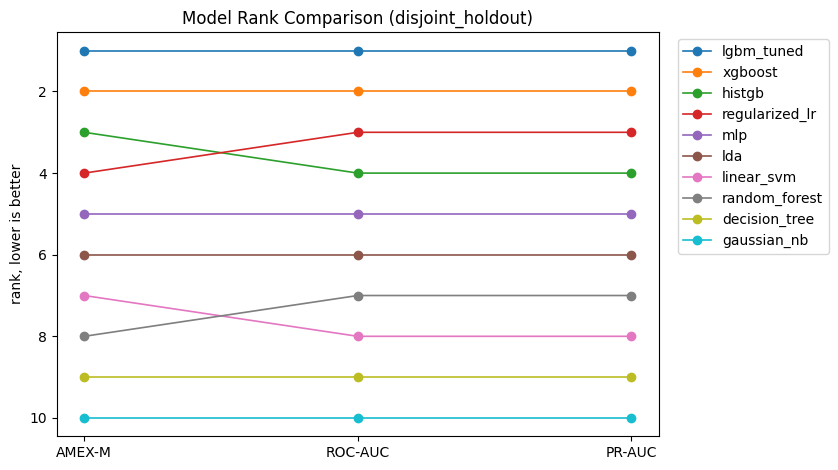

In [5]:
selection_table = holdout_rank if holdout_rank is not None else internal_rank
selection_source = 'disjoint_holdout' if holdout_rank is not None else 'internal_test'
rank_compare = selection_table[['model', 'amex_M', 'roc_auc', 'pr_auc', 'rank_by_amex_M', 'rank_by_roc_auc', 'rank_by_pr_auc']].copy()
rank_compare.insert(0, 'selection_source', selection_source)
rank_compare = rank_compare.sort_values('rank_by_amex_M').reset_index(drop=True)
rank_compare.to_csv(REPORTS / 'amex_metric_rank_comparison.csv', index=False)
display(rank_compare.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
rank_cols = ['rank_by_amex_M', 'rank_by_roc_auc', 'rank_by_pr_auc']
x = np.arange(len(rank_cols))
for _, row in rank_compare.iterrows():
    ax.plot(x, [row[col] for col in rank_cols], marker='o', linewidth=1.2, label=row['model'])
ax.set_xticks(x); ax.set_xticklabels(['AMEX-M', 'ROC-AUC', 'PR-AUC'])
ax.invert_yaxis()
ax.set_ylabel('rank, lower is better')
ax.set_title(f'Model Rank Comparison ({selection_source})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout(); fig.savefig(REPORTS / 'amex_metric_rank_comparison.png', dpi=160); plt.show()


## Final Selection Check

This cell compares the best model by AMEX-M in this notebook with the `final_model` artifact exported
by `04`. The final artifact is not used to choose among families here because it can duplicate a
candidate; it is used as a consistency check.

In [6]:
best = rank_compare.iloc[0]
print(f"Selection source: {selection_source}")
print(f"Best artifact by AMEX-M: {best['model']} with AMEX-M={best['amex_M']:.4f}")
print(f"04 selected final model family: {schema.get('selected_final_model')}")

if 'final_model' in models:
    eval_X = X_holdout if holdout_rank is not None else X_internal
    eval_y = y_holdout if holdout_rank is not None else y_internal
    final_scores = model_scores(models['final_model'], eval_X)
    final_result = pd.DataFrame([{'model': 'final_model', **score_frame(eval_y, final_scores)}])
    final_result.to_csv(REPORTS / 'amex_metric_final_model_check.csv', index=False)
    display(final_result.round(4))


Selection source: disjoint_holdout
Best artifact by AMEX-M: lgbm_tuned with AMEX-M=0.7826
04 selected final model family: lgbm_tuned


,model,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc
0,final_model,0.7826,0.919,0.6462,0.9595,0.897


## Takeaways

Use `amex_M` as the primary **selection** metric when the objective is aligned with the AMEX
competition. The algorithms were trained in `04` with their normal objectives; this notebook only
chooses among the fitted artifacts using the metric that best matches the project goal.

If AMEX-M, ROC-AUC, and PR-AUC agree, the choice is robust. If they disagree, report the disagreement
and select by AMEX-M.

In [7]:
# Export a rendered copy of this finished notebook.
from pathlib import Path
import subprocess
import sys

if Path('05_amex_metric_model_selection.ipynb').exists():
    notebook_path = Path('05_amex_metric_model_selection.ipynb')
    output_dir = Path('../reports/modeling')
elif Path('notebooks/05_amex_metric_model_selection.ipynb').exists():
    notebook_path = Path('notebooks/05_amex_metric_model_selection.ipynb')
    output_dir = Path('reports/modeling')
else:
    raise FileNotFoundError('Could not find 05_amex_metric_model_selection.ipynb from the current working directory.')

output_dir.mkdir(parents=True, exist_ok=True)
output_name = '05_amex_metric_model_selection_finished'
subprocess.run(
    [sys.executable, '-m', 'jupyter', 'nbconvert', '--to', 'html', '--output', output_name,
     '--output-dir', str(output_dir), str(notebook_path)],
    check=True,
)
print(f'saved rendered notebook to {output_dir / (output_name + ".html")}')


[NbConvertApp] Converting notebook 05_amex_metric_model_selection.ipynb to html


saved rendered notebook to ../reports/modeling/05_amex_metric_model_selection_finished.html


[NbConvertApp] Writing 337661 bytes to ../reports/modeling/05_amex_metric_model_selection_finished.html
